# Physics-informed learning across stacks — Part 2: the neural DAE, gradients in both directions

**The series.** "Physics-informed" means different things in different toolchains, and the difference is architectural, not cosmetic. Classical physics-informed neural networks enforce the governing equations through a *residual loss* evaluated at sampled points. [NEUROMANCER](https://github.com/pnnl/neuromancer) — PNNL's PyTorch library for differentiable programming and differentiable predictive control (DPC) — sits in that tradition: physics enters through the loss function and through structured architectures such as bounded policy networks. Jaxonomy takes the complementary route: physics lives in the *solver* — an ODE/DAE right-hand side integrated by a differentiable simulator, so trajectories satisfy the dynamics by construction rather than by penalty (the distinction is spelled out in [the scope note on PINNs](../scope/pinn.md)). The two philosophies compose well, and this three-part series works through the concrete integration patterns, all on the same physical system — a two-tank pump-and-valve network:

![Three integration patterns](media/pinn_across_stacks_patterns.svg)

- **[Part 1 — export and embed](pinn_across_stacks_part_1_policy_export.ipynb).** Train a DPC policy in NEUROMANCER, freeze it to ONNX, and embed it in a jaxonomy diagram as a JAX-traceable block. No gradients cross the stack boundary.
- **Part 2 (this notebook) — gradients cross the boundary, in both directions.** A neural correction learned *inside* an acausal DAE through the implicit BDF solve, and a PyTorch policy trained through the jaxonomy plant via `dlpack`.
- **[Part 3 — tool-neutral FMI co-simulation](pinn_across_stacks_part_3_fmi_cosim.ipynb).** The jaxonomy plant exported as an FMU and stepped in lockstep with the PyTorch policy — verification with no shared runtime at all.

**This part.** The series centerpiece. Part 1 treated the trained network as a frozen artifact; here the two stacks *co-train* — which only works if gradients survive the crossing. We first promote the two-tank rig from Part 1's hand-derived ODE to an acausal **differential-algebraic** model whose manifold pressure is pinned by a flow-balance constraint rather than a formula. Then gradients cross the boundary twice, once in each direction. After reading you will be able to:

- extend jaxonomy's acausal hydraulic domain with custom components (~30 lines each) and let `AcausalCompiler` produce the semi-explicit DAE — 2 differential states, 18 algebraic unknowns,
- train a **physics-structured neural correction inside the DAE** by `jax.value_and_grad` straight through the implicit BDF solve, and validate it as *function recovery* against the injected fault, not just a falling loss,
- wrap the jaxonomy DAE as a NEUROMANCER `Node` — one `torch.autograd.Function` whose backward is the JAX VJP over zero-copy `dlpack` — and train a PyTorch policy through it with NEUROMANCER's own `Trainer`,
- run actuator diagnostics on the final closed loop, and recognize the failure modes specific to learning inside constrained systems.

Estimated reading time: 45 minutes. Runtime: about 1.5 minutes on CPU in the default mode, which loads the offline training checkpoint shipped in `media/`; if the checkpoint is absent the notebook falls back to a reduced live training of both directions (about 4 minutes).

## Prerequisites

We assume familiarity with:

- **Part 1 of this series** — the two-tank rig, the DPC idea, and the export-and-embed pattern. We reuse the physical intuition and the NEUROMANCER vocabulary (`Node`, `System`, `PenaltyLoss`) introduced there.
- **Acausal modeling** — components, ports, `AcausalDiagram.connect`, `AcausalCompiler`. The [multi-domain HVAC tutorial](multi_domain_hvac.ipynb) develops the workflow from scratch; here we go one step further and write *new* components.
- **Neural DAEs in jaxonomy** — the [constrained-pendulum drag recovery tutorial](neural_dae_pendulum_drag.ipynb) introduces `NeuralDAEBlock` on an authored diagram; this notebook uses the post-hoc `add_neural_correction` entry point on a compiled system.
- **DAE projection** — why algebraic states must start on the constraint manifold; see the [projection tutorial](dae_projection_pendulum.ipynb).

Dependencies: `jaxonomy`, `optax`, and `matplotlib` throughout; **`torch` and `neuromancer` are required** (Direction 2 is torch-side training — unlike Part 1, they are not optional here).

In [1]:
# Imports — stdlib, third-party, jaxonomy. Logging is quieted so the
# simulator's per-run INFO banner doesn't clutter the notebook output.
import inspect
import os
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optax
import sympy as sp

import jax
import jax.numpy as jnp
from jax.flatten_util import ravel_pytree

import torch
import torch.nn as nn

import jaxonomy as jx
from jaxonomy import logging as jaxlog
from jaxonomy.acausal import AcausalCompiler, AcausalDiagram, EqnEnv
from jaxonomy.acausal.component_library.base import SymKind
from jaxonomy.acausal.component_library.hydraulic import (
    HydraulicOnePort,
    HydraulicTwoPort,
)
from jaxonomy.diagnostics import analyze_control_oscillation, analyze_saturation
from jaxonomy.library import Constant
from jaxonomy.library.neural_dae import add_neural_correction
from jaxonomy.simulation.dae_drift import algebraic_row_mask
from jaxonomy.simulation.dae_projection import project_constraints

jaxlog.set_log_level(jaxlog.ERROR)
plt.rcParams["figure.dpi"] = 110

# The shared plant module: the network *builder* lives in media/ so this
# notebook and the offline publication script consume one source of truth.
sys.path.insert(0, str(Path("media").resolve()))
import pinn_tank_network_dae as tank_plant

SEED = 0  # one seed for the whole notebook (jax PRNG key and torch)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"jax {jax.__version__} | torch {torch.__version__} | "
      f"x64 enabled: {jax.config.jax_enable_x64}")

jax 0.9.2 | torch 2.13.0 | x64 enabled: True


## 1. From ODE to DAE — when a variable has no formula

Part 1's plant was honest but hand-made: two mass balances whose right-hand sides we derived ourselves, every flow written out explicitly. Real process rigs are *networks*, and on a network that derivation stops being free. Our upgraded rig:

```
reservoir ──(pump, power u_p)──▶ manifold ──(valve A, opening u_a)──▶ tank 1
                                 manifold ──(valve B, opening u_b)──▶ tank 2
                                 manifold ──(small bypass)──▶ reservoir
tank 1 ──(fixed orifice)──▶ tank 2 ──(drain orifice)──▶ reservoir
```

A pump draws from a reservoir and feeds a **3-way manifold** that splits flow between the two tanks through a pair of commanded valves; tank 1 also drains into tank 2 through a fixed orifice, tank 2 drains back to the reservoir, and a small always-open bypass relieves the manifold. The control task will again be level tracking with the pump power and the valve split.

Here is the structural difference from Part 1: **the manifold pressure $P_m$ is not given by any formula.** Every flow *into and out of* the manifold depends on $P_m$, and $P_m$ is whatever value makes those flows balance — an algebraic constraint, not an assignment. The model is a **semi-explicit DAE**:

$$M \dot{\mathbf{x}} = f(\mathbf{x}, \mathbf{y}, \mathbf{u}), \qquad 0 = g(\mathbf{x}, \mathbf{y}, \mathbf{u}), \tag{1}$$

with differential states $\mathbf{x}$ (the tank levels), algebraic unknowns $\mathbf{y}$ ($P_m$ and every internal flow and pressure drop), inputs $\mathbf{u} = (u_p, u_a, u_b)$, and a **singular mass matrix** $M = \mathrm{diag}(1, \dots, 1, 0, \dots, 0)$.

For *this* network you could still eliminate $P_m$ by hand — the balance is a scalar root-find. But that elimination is what dies on every topology change (add a tank, tee off a line, swap a valve law), and it is exactly the labor the acausal route removes: declare components, connect ports, and the constraint falls out of the connection semantics. That matters for this series because both learning problems below — a neural term *inside* the DAE, and a policy trained *through* it — must respect $g = 0$ while gradients flow.

## 2. The component physics

Three component laws build the whole network. We state each with its intuition, then its units.

**Gravity tank.** An open tank filled to level $h$ presents hydrostatic pressure at its bottom port, and net inflow raises the level:

$$P = \rho g h, \qquad \rho A \,\dot h = M_{\text{net}}, \tag{2}$$

with $M_{\text{net}}$ the net mass inflow. Dimensions: $[\rho g h] = \frac{\text{kg}}{\text{m}^3}\frac{\text{m}}{\text{s}^2}\text{m} = \text{Pa}$ ✓, and $[M/(\rho A)] = \frac{\text{kg/s}}{\text{kg/m}^3 \cdot \text{m}^2} = \text{m/s}$ ✓. The level is the differential state.

**Square-root valve / orifice.** Torricelli again, as in Part 1, but now written on a pressure drop $\Delta P$ rather than a level, and *regularized* so the law is smooth at $\Delta P = 0$:

$$M = u_v\, k\, \frac{\Delta P}{\left(\Delta P^2 + \varepsilon\right)^{1/4}} \;\approx\; u_v\, k\, \operatorname{sign}(\Delta P)\sqrt{|\Delta P|}, \tag{3}$$

where $u_v \in [0,1]$ is the commanded opening (a parameter for fixed orifices). With $\Delta P \sim 10^3\,\text{Pa}$ in this network, $\varepsilon = 1\,\text{Pa}^2$ biases the law by well under 0.01% while keeping the implicit solver's Newton iterations away from the infinite slope of a bare $\sqrt{|\Delta P|}$ at zero. Since $[k\sqrt{\text{Pa}}] = \text{kg/s}$, the coefficient $k$ carries units $\text{kg}/(\text{s}\cdot\text{Pa}^{1/2})$.

**Ideal pump.** The library `Pump` converts input power $u_p$ to mass flow against its pressure rise, up to a maximum rise $\Delta P_{\max}$:

$$M_p = \frac{u_p\, C}{\Delta P_{\max} - \Delta P}. \tag{4}$$

Solving $[M_p] = \text{kg/s}$ for $C$ gives $C$ in $\text{kg}\cdot\text{Pa}/(\text{W}\cdot\text{s})$: at $u_p = 50\,\text{W}$, $C = 80$, and $\Delta P \approx 3.5\,\text{kPa}$ the pump delivers $\approx 0.15$ kg/s — a sensible bench-rig scale.

**The manifold.** No component at all — it is a *node*. Acausal connection semantics impose the Kirchhoff-style balance

$$0 = M_p - M_A - M_B - M_{\text{byp}} \tag{5}$$

at the junction, and $P_m$ is the algebraic unknown that satisfies it.

> **Pitfall — the pump law degenerates at zero power.** Differentiate eq. (4): $\partial M_p / \partial \Delta P = u_p C / (\Delta P_{\max} - \Delta P)^2 \to 0$ as $u_p \to 0$. At zero power the pump passes zero flow *regardless of* $\Delta P$, so eq. (5) loses all sensitivity to $P_m$ through the pump branch and the constraint Jacobian can lose its pivot — the Newton solve for $\mathbf{y}$ goes singular. Two guards appear in this notebook because of this: the **always-open bypass** ($k_{\text{byp}} = 5\times10^{-5}$, a relief path that keeps $\partial g/\partial P_m \neq 0$ unconditionally) and a **pump floor** of 5% baked into the trained policy's output bounds in Direction 2.

| Symbol | Meaning | Units | Value |
|---|---|---|---|
| $h_1, h_2$ | tank levels (differential states) | m | ICs $0.40,\ 0.15$ |
| $A_1, A_2$ | tank cross-sections | m² | $0.02,\ 0.03$ |
| $\rho$ | water density | kg/m³ | $1000$ |
| $g$ | gravitational acceleration | m/s² | $9.81$ |
| $P_m$ | manifold pressure (algebraic) | Pa | solved from eq. (5) |
| $u_p$ | pump power (input) | W | $[0, 100]$ |
| $u_a, u_b$ | valve A / B openings (inputs) | – | $[0, 1]$ |
| $k_{\text{in}}, k_{12}, k_{\text{out}}, k_{\text{byp}}$ | valve/orifice coefficients | kg/(s·Pa$^{1/2}$) | $6\!\cdot\!10^{-3},\ 3\!\cdot\!10^{-3},\ 2\!\cdot\!10^{-3},\ 5\!\cdot\!10^{-5}$ |
| $\varepsilon$ | orifice regularization | Pa² | $1.0$ |
| $\Delta P_{\max}$ | pump max pressure rise | Pa | $3\times10^{4}$ |
| $C$ | pump performance coefficient | kg·Pa/(W·s) | $80$ |
| $\delta m$ | neural flow correction (Direction 1) | kg/s | $|\delta m| \le 0.15$ |

In [2]:
# ---- physical configuration (matches media/pinn_tank_network_dae.py) ------
RHO, G_N = 1000.0, 9.81        # water density [kg/m^3], gravity [m/s^2]
A1, A2 = 0.02, 0.03            # tank cross-sections [m^2]
H1_IC, H2_IC = 0.40, 0.15      # initial levels [m]
K12_NOMINAL = 3e-3             # tank1->tank2 orifice coefficient [kg/(s*Pa^0.5)]
K12_TRUE = 0.55 * K12_NOMINAL  # truth: partially clogged — the model won't know
EPS_V = 1.0                    # valve sqrt regularization [Pa^2]

# Build-time input placeholders, centered in the operating envelope. The
# compiler solves the algebraic initial values *for these inputs*, and they
# seed every later Newton projection — a far-off placeholder (say, pump at
# 0.1 W) makes those projections diverge for some operating points.
CENTER = {"pump_power": 50.0, "valve_a_opening": 0.5, "valve_b_opening": 0.5}

## 3. Custom acausal components

This section extends jaxonomy's hydraulic domain (potential = pressure [Pa], flow = mass flow [kg/s]) with the two components the library doesn't ship: `GravityTank` and `SqrtValve`. Each is ~30 lines, and together they demonstrate the full anatomy of an acausal component:

- **Symbols** are declared with a `SymKind`: `param` (compile-time constant, validated), `var` (an unknown the compiler solves for — the tank declares the level `h` and its derivative `dh`, chained via `int_sym`/`der_sym`), `inp`/`outp` (causal signal ports — the valve's commanded opening enters the equations as an ordinary input signal).
- **Equations** are sympy relations added with `add_eqs`. Equations that need *network-level* information — here the fluid density, which is only known once a `HydraulicProperties` component tags the circuit — go in **`finalize()`**, which the compiler calls after assembly.
- **Initial conditions**: the tank pins its port pressure with a *strong* IC (`P_ic_fixed=True`, computed as $\rho g h_0$). Without it the compiler's IC search is free to flatten the levels to zero.

Note the design choice in `SqrtValve`: `enable_opening_port` switches the opening between a causal input (the commanded valves) and a plain parameter (the fixed orifices) — one component class, both roles.

> **Note — one source of truth.** The two classes below are reproduced **inline as teaching material**; the network *builder* is imported from [`media/pinn_tank_network_dae.py`](media/pinn_tank_network_dae.py), which the offline publication script also imports. The next cell asserts the inline copies' methods are byte-identical to the module's (`inspect.getsource`), so the teaching copy cannot silently drift from the executed one.

Contrast with Part 1, which implemented its two-tank ODE as a single causal block with a hand-written RHS: the causal route encapsulates (you own the equations, the block is opaque but portable), while the acausal route is declarative (you own component *laws*; topology, constraint, and index analysis are the compiler's job). For a fixed textbook model the causal block is simpler; the moment the topology grows a junction whose pressure nobody can write down, acausal wins.

In [3]:
class GravityTank(HydraulicOnePort):
    """Open gravity-drained tank; port at the bottom.

    P_port = rho*g*h (gauge),  A*rho*der(h) = M_net.
    The level h is the differential state.
    """

    def __init__(self, ev, name=None, area=1.0, h_ic=0.5, rho_ref=1000.0):
        self.name = self.__class__.__name__ if name is None else name
        # port pressure IC must be strong (fixed) or the compiler's IC search
        # flattens the levels to zero; rho_ref must match the fluid density.
        super().__init__(
            ev, self.name, P_ic=rho_ref * G_N * h_ic, P_ic_fixed=True
        )
        self.area = self.declare_symbol(
            ev, "area", self.name, kind=SymKind.param, val=area,
            validator=lambda a: a > 0.0,
            invalid_msg=f"GravityTank {self.name} must have area>0",
        )
        self.h = self.declare_symbol(ev, "h", self.name, kind=SymKind.var, ic=h_ic)
        self.dh = self.declare_symbol(
            ev, "dh", self.name, kind=SymKind.var, int_sym=self.h, ic=0.0
        )
        self.h.der_sym = self.dh
        # level sensor output (causal)
        h_out = self.declare_symbol(ev, "h_out", self.name, kind=SymKind.outp)
        from jaxonomy.acausal.component_library.base import EqnKind
        self.declare_equation(sp.Eq(h_out.s, self.h.s), kind=EqnKind.outp)

    def finalize(self, ev):
        fluid = self.ports["port"].fluid
        self.add_eqs(
            [
                # bottom pressure from hydrostatic head (gauge)
                sp.Eq(self.P.s, fluid.density * G_N * self.h.s),
                # mass balance: net inflow raises the level
                sp.Eq(self.dh.s, self.M.s / (fluid.density * self.area.s)),
            ]
        )


class SqrtValve(HydraulicTwoPort):
    """Orifice with square-root pressure-flow law and causal opening input.

    M1 = opening * k * dP / (dP^2 + eps)^(1/4)
       ~ opening * k * sign(dP) * sqrt(|dP|),  smooth at dP = 0.

    opening: causal input in [0, 1] if enable_opening_port else a parameter.
    """

    def __init__(self, ev, name=None, k=1.0, opening=1.0,
                 enable_opening_port=False, eps=1.0):
        # eps regularizes the sqrt at dP=0: slope there is k/eps^(1/4).
        # With dP in Pa (~1e3 in this network) eps=1.0 biases the law by
        # <0.01% while keeping the Newton iterations well-conditioned;
        # eps=1e-4 made the BDF corrector fragile on some compiles.
        self.name = self.__class__.__name__ if name is None else name
        super().__init__(ev, self.name)
        k = self.declare_symbol(
            ev, "k", self.name, kind=SymKind.param, val=k,
            validator=lambda k: k > 0.0,
            invalid_msg=f"SqrtValve {self.name} must have k>0",
        )
        if enable_opening_port:
            opening = self.declare_symbol(ev, "opening", self.name, kind=SymKind.inp)
        else:
            opening = self.declare_symbol(
                ev, "opening", self.name, kind=SymKind.param, val=opening
            )
        eps = sp.Float(eps)
        self.add_eqs(
            [
                sp.Eq(0, self.M1.s + self.M2.s),
                sp.Eq(
                    self.M1.s,
                    opening.s * k.s * self.dP.s / (self.dP.s**2 + eps) ** sp.Rational(1, 4),
                ),
            ]
        )

With the components defined, assembly is nine `connect` calls (see `build_network` in the module). The one to appreciate is the manifold: **three components connected to the same node is the entire implementation of the 3-way junction** — eq. (5) is generated by the connection semantics, not written by anyone.

We compile with `scale=True`, which normalizes each differential state by its initial condition — the raw Jacobian mixes pascals ($\sim 10^3$) with dimensionless openings, and the scaling keeps the BDF Newton matrices well-conditioned. (The compiler's IC-conditioning check runs on the *raw* system before scaling is applied, so it would warn spuriously here; the cell silences exactly that message and nothing else.)

In [4]:
# Drift guard: the inline teaching copies must match the shared module.
# (Method-level comparison: on Python < 3.13, inspect can't source a *class*
# defined in a notebook cell, but methods carry their cell's source.)
for nb_cls, mod_cls in ((GravityTank, tank_plant.GravityTank),
                        (SqrtValve, tank_plant.SqrtValve)):
    for meth in nb_cls.__dict__:
        if callable(nb_cls.__dict__[meth]):
            assert (inspect.getsource(getattr(nb_cls, meth))
                    == inspect.getsource(getattr(mod_cls, meth))), meth
assert G_N == tank_plant.G_N
print("inline component copies match media/pinn_tank_network_dae.py")

ev = EqnEnv()
ad = AcausalDiagram()
comps = tank_plant.build_network(ev, ad, h1_ic=H1_IC, h2_ic=H2_IC)

t0 = time.perf_counter()
with warnings.catch_warnings():
    # The IC-conditioning check fires on the raw (pre-scaling) Jacobian;
    # with scale=True the integrated system is the well-conditioned one.
    warnings.filterwarnings("ignore", message=".*ill-conditioned Jacobian.*")
    tank_sys = AcausalCompiler(ev, ad, scale=True)(name="tank_dae", leaf_backend="jax")
print(f"compile time: {time.perf_counter() - t0:.0f}s "
      f"(symbolic flattening + index analysis + codegen)")

print(f"n_ode = {tank_sys.n_ode:2d} differential states (scaled tank levels)")
print(f"n_alg = {tank_sys.n_alg:2d} algebraic unknowns "
      f"(manifold pressure, every component dP and mass flow)")
print("causal inputs :", [p.name for p in tank_sys.input_ports])
print("causal outputs:", [p.name for p in tank_sys.output_ports])

inline component copies match media/pinn_tank_network_dae.py


compile time: 2s (symbolic flattening + index analysis + codegen)
n_ode =  2 differential states (scaled tank levels)
n_alg = 18 algebraic unknowns (manifold pressure, every component dP and mass flow)
causal inputs : ['pump_power', 'valve_a_opening', 'valve_b_opening']
causal outputs: ['tank1_h_out', 'tank2_h_out']


Twenty continuous unknowns, of which only two carry a derivative. The compiled `AcausalSystem` is an ordinary jaxonomy `LeafSystem` whose continuous state stacks $[\mathbf{x}; \mathbf{y}]$ with the singular mass matrix of eq. (1) attached — the BDF solver accepts it directly (implicit multistep methods solve a Newton system each step anyway, so the zero rows of $M$ cost nothing extra; an explicit RK solver would reject the system).

Let's wire the three causal inputs to constants at the centered operating point and watch the open loop settle.

In [5]:
builder = jx.DiagramBuilder()
s = builder.add(tank_sys)
plant_consts = {}
for i, p in enumerate(tank_sys.input_ports):
    c = builder.add(Constant(np.array(CENTER[p.name])))
    builder.connect(c.output_ports[0], s.input_ports[i])  # causal source -> DAE input
    plant_consts[p.name] = c
plant_diagram = builder.build()
plant_ctx0 = plant_diagram.create_context()
PLANT_SID = tank_sys.system_id

mask = algebraic_row_mask(plant_diagram)
print(f"continuous state vector: {mask.shape[0]} entries "
      f"({int((~mask).sum())} differential + {int(mask.sum())} algebraic)")

SIM_OPTS = jx.SimulatorOptions(math_backend="jax", ode_solver_method="bdf",
                               rtol=1e-7, atol=1e-9)
rec = {"h1": tank_sys.output_ports[0], "h2": tank_sys.output_ports[1]}
t0 = time.perf_counter()
res = jx.simulate(plant_diagram, plant_ctx0, (0.0, 60.0),
                  recorded_signals=rec, options=SIM_OPTS)
print(f"open-loop BDF solve of the singular-mass-matrix system: "
      f"{time.perf_counter() - t0:.1f}s (includes jit)")
t_ol = np.asarray(res.time)
h1_ol, h2_ol = np.asarray(res.outputs["h1"]), np.asarray(res.outputs["h2"])
print(f"levels at t=60 s: h1 = {h1_ol[-1]:.4f} m, h2 = {h2_ol[-1]:.4f} m")

continuous state vector: 20 entries (2 differential + 18 algebraic)


open-loop BDF solve of the singular-mass-matrix system: 0.7s (includes jit)
levels at t=60 s: h1 = 0.2893 m, h2 = 0.2666 m


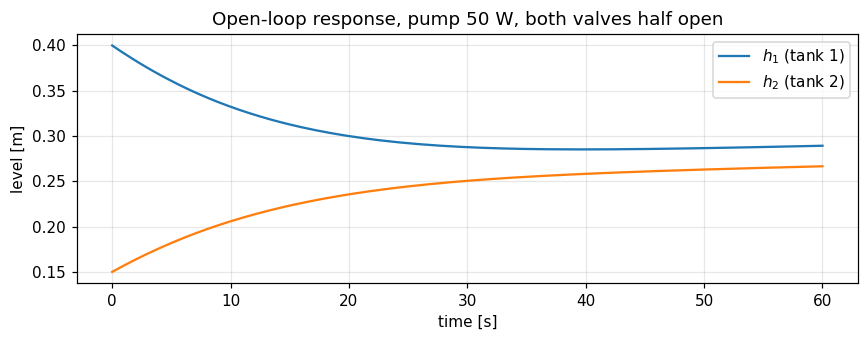

In [6]:
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(t_ol, h1_ol, label="$h_1$ (tank 1)")
ax.plot(t_ol, h2_ol, label="$h_2$ (tank 2)")
ax.set_xlabel("time [s]")
ax.set_ylabel("level [m]")
ax.set_title("Open-loop response, pump 50 W, both valves half open")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

*Figure 1: open-loop tank levels at the centered operating point; blue = tank 1, orange = tank 2. Tank 1 drains toward tank 2 through the fixed orifice while the pump replenishes both through the manifold; the levels relax toward a balance where inflow through each valve matches each tank's outflow.*

Now that the constrained plant simulates, we turn to the first boundary crossing.

## 4. Direction 1 — learn *inside* the DAE

**The scenario.** The physical rig has a fault the model doesn't know about: the tank1→tank2 orifice is **partially clogged** — its true coefficient is $k_{12}^{\text{true}} = 0.55\,k_{12}^{\text{nom}}$. Our model carries the nominal value. The data available to fix this is deliberately scarce and realistic: **terminal level pairs only** — the plant is run from the same initial condition under 3 excitations (pump power and valve split settings), each measured at 3 horizons (8, 16, 32 s). Nine experiments, eighteen numbers. No trajectories, no flow sensors.

**The approach.** Keep the physics, add a *bounded neural correction* to the differential rows of the compiled DAE, and fit its parameters $\theta$ by differentiating the simulation itself:

$$\mathcal{L}(\theta) = \frac{1}{9}\sum_{e}\sum_{T} \left\| \hat{\mathbf{h}}_\theta(T; e) - \mathbf{h}^{\text{true}}(T; e) \right\|^2, \qquad \theta \leftarrow \text{Adam}\big(\nabla_\theta \mathcal{L}\big),$$

where $\hat{\mathbf{h}}_\theta(T;e)$ is the *simulated* terminal level pair — every gradient evaluation is reverse-mode AD **through the implicit BDF solve** of the constrained system, Newton iterations, adaptive steps, and all. The injection point is `add_neural_correction`, which wraps a compiled system's RHS so the differential rows become $f + \text{scatter}(f_{\text{NN}}(t, \mathbf{x}; \theta))$ while the algebraic rows — and the index analysis that produced them — stay untouched. (Its diagram-authored sibling is `NeuralDAEBlock`, which targets *physical component states* before compilation; see the [pendulum drag tutorial](neural_dae_pendulum_drag.ipynb).)

The multi-excitation × multi-horizon design is not decoration — it is the entire identifiability budget. One excitation constrains the correction only along one trajectory through the $(h_1, h_2)$ plane; three settings at three horizons scatter nine probe points across an operating *region*, which is the minimum leverage for recovering a function of two variables.

In [7]:
# ============================================================
# Mode toggle. Default = publication: load the results of the
# full offline runs (media/pinn_across_stacks_part_2_publication_offline.py,
# ~30 min on CPU) from the NPZ checkpoint. If the NPZ is absent,
# fall back to FAST mode: reduced live trainings (~5 min total).
# ============================================================
PUB_NPZ = "media/pinn_across_stacks_part_2_publication.npz"
USE_PUBLICATION = os.path.exists(PUB_NPZ)

if USE_PUBLICATION:
    pub = dict(np.load(PUB_NPZ).items())
    assert not bool(pub["placeholder_flag"]), "NPZ carries placeholder numbers"
    print(f"PUBLICATION mode — loaded {PUB_NPZ}:")
    print(f"  direction 1: {pub['d1_hist'].size} Adam iterations "
          f"({float(pub['d1_train_wall_s']):.0f}s offline)")
    print(f"  direction 2: {int(pub['d2_epochs'])} epochs "
          f"({float(pub['d2_train_wall_s']) / 60:.1f} min offline)")
else:
    pub = None
    print("FAST mode — publication NPZ not found.")
    print("  Reduced excitation set, iteration and epoch counts run live.")
    print("  To regenerate the checkpoint:")
    print("    cd media && PYTHONHASHSEED=0 python "
          "pinn_across_stacks_part_2_publication_offline.py")

PUBLICATION mode — loaded media/pinn_across_stacks_part_2_publication.npz:
  direction 1: 150 Adam iterations (24s offline)
  direction 2: 15 epochs (11.8 min offline)


The two helpers below are shared by everything downstream. `build_and_wire` compiles a network (optionally with a neural correction bolted on) and wires the centered input placeholders. `set_excitation` changes the operating point — and packs two pitfalls that cost us real debugging time:

> **Pitfall 1 — a state reset leaves the algebraic rows inconsistent.** The context's algebraic entries were solved for the *build-time* inputs. Change the pump power and they no longer satisfy $g=0$; starting BDF off the constraint manifold produces `NaN` within a step or two. The fix is `project_constraints`: a Newton solve of the algebraic rows holding the differential states fixed.
>
> **Pitfall 2 — don't differentiate through the projection.** The projected $\mathbf{y}_0$ is an implicit function of $(\mathbf{x}_0, \mathbf{u})$ that the solver re-enforces at every subsequent step anyway. Reverse-AD through the *unrolled Newton iterations* (32 of them, from a possibly far-off guess) contaminates the gradient — we verified against finite differences that it is the value-only form, `x + stop_gradient(proj - x)`, that matches. The projection contributes its **value**; sensitivity flows through the solve itself.

In [8]:
def build_and_wire(k_12, nn_pair=None):
    """Compile the tank network (optionally with a neural correction) and
    wire centered Constant placeholders on the three causal inputs."""
    ev = EqnEnv()
    ad = AcausalDiagram()
    tank_plant.build_network(ev, ad, h1_ic=H1_IC, h2_ic=H2_IC, k_12=k_12)
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message=".*ill-conditioned Jacobian.*")
        system = AcausalCompiler(ev, ad, scale=True)(name="tank_dae",
                                                     leaf_backend="jax")
    if nn_pair is not None:
        add_neural_correction(system, nn_pair[0], nn_pair[1], param_name="nn_theta")
    b = jx.DiagramBuilder()
    sys_ = b.add(system)
    consts = {}
    for i, p in enumerate(system.input_ports):
        c = b.add(Constant(np.array(CENTER[p.name])))
        b.connect(c.output_ports[0], sys_.input_ports[i])
        consts[p.name] = c
    return b.build(), sys_, consts


def set_excitation(diagram, diagram_ctx, consts, sid, exc):
    """Set (pump_power, valve_a, valve_b) and re-project the algebraic state.

    Value-only projection: the Newton correction enters as a constant shift
    (stop_gradient), so gradients flow through the DAE solve, not through
    the unrolled projection iterations. See the two pitfalls above.
    """
    vals = dict(zip(("pump_power", "valve_a_opening", "valve_b_opening"), exc))
    ctx = diagram_ctx
    for name, v in vals.items():
        cid = consts[name].system_id
        ctx = ctx.with_subcontext(cid, ctx[cid].with_parameter("value",
                                                               jnp.asarray(v)))
    proj = project_constraints(diagram, ctx, tol=1e-12, max_iter=32)
    raw = ctx[sid].continuous_state
    fixed = raw + jax.lax.stop_gradient(proj[sid].continuous_state - raw)
    return ctx.with_subcontext(sid, ctx[sid].with_continuous_state(fixed))

In [9]:
HORIZONS = (8.0, 16.0, 32.0)
EXCITATIONS = ((50.0, 0.5, 0.5), (80.0, 0.8, 0.2), (30.0, 0.2, 0.8))
FLOW_SCALE = 0.15  # bound on |dm| [kg/s]; the injected deficit peaks ~0.08

# fast mode trains on a reduced 2 x 2 subset (see the note below)
FAST_EXCITATIONS = EXCITATIONS[:2]
FAST_HORIZONS = HORIZONS[:2]
FAST_ITERS = 8

AD_OPTS = jx.SimulatorOptions(math_backend="jax", ode_solver_method="bdf",
                              rtol=1e-7, atol=1e-9, enable_autodiff=True,
                              max_major_steps=400)
# truth data: tighter tolerances, no autodiff machinery
TRUTH_OPTS = jx.SimulatorOptions(math_backend="jax", ode_solver_method="bdf",
                                 rtol=1e-8, atol=1e-10, enable_autodiff=False,
                                 max_major_steps=600)

if USE_PUBLICATION:
    targets = {}
    for i, e in enumerate(EXCITATIONS):
        for j, T in enumerate(HORIZONS):
            targets[(e, T)] = np.asarray(pub["d1_targets"][i * len(HORIZONS) + j])
    print("truth targets (terminal levels of the clogged plant, offline run):")
else:
    t0 = time.perf_counter()
    truth_diagram, truth_s, truth_consts = build_and_wire(K12_TRUE)
    truth_ctx0 = truth_diagram.create_context()

    def truth_levels(exc, T):
        ctx = set_excitation(truth_diagram, truth_ctx0, truth_consts,
                             truth_s.system_id, exc)
        r = jx.simulate(truth_diagram, ctx, (0.0, T), options=TRUTH_OPTS)
        return np.array([float(truth_s.output_ports[0].eval(r.context)),
                         float(truth_s.output_ports[1].eval(r.context))])

    targets = {(e, T): truth_levels(e, T)
               for e in FAST_EXCITATIONS for T in FAST_HORIZONS}
    print(f"truth targets (fast 2x2 subset, generated live in "
          f"{time.perf_counter() - t0:.0f}s):")

for (e, T), v in targets.items():
    assert np.isfinite(v).all()
    print(f"  pump={e[0]:5.1f} W  openings=({e[1]:.1f}, {e[2]:.1f})  "
          f"T={T:4.0f} s  ->  h = ({v[0]:.4f}, {v[1]:.4f}) m")

truth targets (terminal levels of the clogged plant, offline run):
  pump= 50.0 W  openings=(0.5, 0.5)  T=   8 s  ->  h = (0.3622, 0.1844) m
  pump= 50.0 W  openings=(0.5, 0.5)  T=  16 s  ->  h = (0.3373, 0.2087) m
  pump= 50.0 W  openings=(0.5, 0.5)  T=  32 s  ->  h = (0.3137, 0.2371) m
  pump= 80.0 W  openings=(0.8, 0.2)  T=   8 s  ->  h = (0.4138, 0.1682) m
  pump= 80.0 W  openings=(0.8, 0.2)  T=  16 s  ->  h = (0.4277, 0.1850) m
  pump= 80.0 W  openings=(0.8, 0.2)  T=  32 s  ->  h = (0.4554, 0.2152) m
  pump= 30.0 W  openings=(0.2, 0.8)  T=   8 s  ->  h = (0.3519, 0.1798) m
  pump= 30.0 W  openings=(0.2, 0.8)  T=  16 s  ->  h = (0.3132, 0.2016) m
  pump= 30.0 W  openings=(0.2, 0.8)  T=  32 s  ->  h = (0.2626, 0.2245) m


### 4.1 Structure the correction like the physics — or fail to identify

The obvious correction is an unstructured one: a small MLP $(h_1, h_2) \mapsto (\delta \dot h_1, \delta \dot h_2)$ added to both level equations. **It fits the data and it is still wrong.** When we trained exactly that on this problem, the loss fell about 90× — and the recovered field correlated only 0.7–0.8 with the true injected residual. Nine terminal-state probes cannot pin down an unconstrained 2-in/2-out vector field; the optimizer happily explains the data with a function that is wrong everywhere between the probe points. The loss curve alone would never tell you.

The fix costs one line of physics. *The unknown is a flow between the tanks.* Whatever the clog does, it removes some mass flow $\delta m(h_1, h_2)$ from the orifice — and a flow between two tanks enters the level equations with a **fixed, opposite-signed ratio** given by eq. (2):

$$\delta \dot h_1 = -\frac{\delta m}{\rho A_1}, \qquad \delta \dot h_2 = +\frac{\delta m}{\rho A_2}. \tag{6}$$

So the MLP outputs **one scalar** $\delta m$ (tanh-bounded by `FLOW_SCALE` = 0.15 kg/s), scattered into the two rows with the ratio of eq. (6) — a rank-1 prior on the correction field. Mass conservation between the tanks is now structural: no parameter setting can violate it, and the nine probes only have to identify a scalar function. This is the same "physics in the architecture" idea NEUROMANCER applies to its bounded policies, used *inside* a DAE's right-hand side.

One bookkeeping detail: the compiler's `scale=True` states are $h/h_{0}$, so a physical $\delta\dot h$ converts to scaled rows via $1/h_0$ — that is the `SC_ROWS` factor below.

In [10]:
key = jax.random.PRNGKey(SEED)
k1, k2 = jax.random.split(key)
W_H = 8  # hidden width; theta = 2*8 + 8 + 8 + 1 = 33 parameters
params0 = {"w1": 0.5 * jax.random.normal(k1, (2, W_H)), "b1": jnp.zeros(W_H),
           "w2": 0.1 * jax.random.normal(k2, (W_H, 1)), "b2": jnp.zeros(1)}
theta0, unravel = ravel_pytree(params0)

# scale=True states are h / h_ic, so d(scaled)/dt = (dh/dt) / h_ic
SC_ROWS = jnp.array([1.0 / H1_IC, 1.0 / H2_IC])


def nn_fn(t, x_diff, theta):
    """Physics-structured correction: ONE scalar flow dm(h1, h2) [kg/s],
    tanh-bounded by FLOW_SCALE, entering both level equations with the
    fixed physical ratio of eq. (6)."""
    p = unravel(theta)
    z = jnp.tanh(x_diff @ p["w1"] + p["b1"])
    dm = FLOW_SCALE * jnp.tanh(z @ p["w2"] + p["b2"])[0]
    dh = jnp.array([-dm / (RHO * A1), dm / (RHO * A2)])  # eq. (6)
    return dh * SC_ROWS  # physical dh/dt -> scaled-state rows


t0 = time.perf_counter()
model_diagram, model_s, model_consts = build_and_wire(
    K12_NOMINAL, nn_pair=(nn_fn, theta0))
model_ctx0 = model_diagram.create_context()
MODEL_SID = model_s.system_id
print(f"model plant (nominal k12 + neural correction) compiled in "
      f"{time.perf_counter() - t0:.0f}s")
print(f"theta: {theta0.size} parameters; correction bound |dm| <= "
      f"{FLOW_SCALE} kg/s")

model plant (nominal k12 + neural correction) compiled in 1s
theta: 33 parameters; correction bound |dm| <= 0.15 kg/s


### 4.2 The gradient exists — and it is correct

Before training on a claim like "gradients flow through the implicit solver", check it. `jax.value_and_grad` of the loss *is* reverse-mode AD through: the Newton projection value, the adaptive BDF stepper, its per-step Newton solves with the singular mass matrix, and the terminal output evaluation. We verify against central finite differences.

The live check below differentiates a bounded version of the loss (one simulation in publication mode — the full 9-simulation loss is what the offline run compiles, at ~100 s of jit; fast mode compiles its actual 2×2 training loss here and reuses it). The offline run's check on the full loss is reprinted from the checkpoint.

In [11]:
targets_j = {k: jnp.asarray(v) for k, v in targets.items()}


def terminal_levels(theta, exc, T):
    """Simulated terminal level pair of the corrected model."""
    ctx = set_excitation(model_diagram, model_ctx0, model_consts, MODEL_SID, exc)
    ctx = ctx.with_subcontext(MODEL_SID,
                              ctx[MODEL_SID].with_parameter("nn_theta", theta))
    r = jx.simulate(model_diagram, ctx, (0.0, T), options=AD_OPTS)
    return jnp.array([model_s.output_ports[0].eval(r.context),
                      model_s.output_ports[1].eval(r.context)]).reshape(-1)


def make_loss(pairs):
    def loss_fn(theta):
        l = 0.0
        for (e, T) in pairs:
            l = l + jnp.sum((terminal_levels(theta, e, T) - targets_j[(e, T)]) ** 2)
        return l / len(pairs)
    return loss_fn


if USE_PUBLICATION:
    LIVE_PAIRS = [(EXCITATIONS[0], HORIZONS[0])]  # one simulation, live beat
else:
    LIVE_PAIRS = [(e, T) for e in FAST_EXCITATIONS for T in FAST_HORIZONS]
vg_live = jax.jit(jax.value_and_grad(make_loss(LIVE_PAIRS)))

t0 = time.perf_counter()
l_live, g_live = vg_live(theta0)
print(f"first value_and_grad through the BDF solve ({len(LIVE_PAIRS)} sim(s), "
      f"incl jit): {time.perf_counter() - t0:.0f}s, loss = {float(l_live):.4e}")

eps = 1e-4
print("AD vs central finite differences (reusing the jitted function):")
for i in (0, 25):
    e_vec = jnp.zeros_like(theta0).at[i].set(eps)
    fd = (float(vg_live(theta0 + e_vec)[0])
          - float(vg_live(theta0 - e_vec)[0])) / (2 * eps)
    ad = float(g_live[i])
    print(f"  dL/dtheta[{i:2d}]:  AD = {ad:+.5e}   FD = {fd:+.5e}   "
          f"rel diff = {abs(ad - fd) / max(abs(fd), 1e-30):.1e}")

if USE_PUBLICATION:
    print("\noffline run, full 9-simulation loss "
          f"(first value_and_grad incl jit: {float(pub['d1_first_grad_s']):.0f}s):")
    for i, ad, fd in zip(pub["d1_grad_idx"], pub["d1_grad_ad"], pub["d1_grad_fd"]):
        print(f"  dL/dtheta[{int(i):2d}]:  AD = {ad:+.5e}   FD = {fd:+.5e}")

first value_and_grad through the BDF solve (1 sim(s), incl jit): 7s, loss = 7.2034e-04
AD vs central finite differences (reusing the jitted function):
  dL/dtheta[ 0]:  AD = -4.32961e-04   FD = -4.32981e-04   rel diff = 4.6e-05
  dL/dtheta[25]:  AD = -2.08791e-04   FD = -2.08889e-04   rel diff = 4.7e-04

offline run, full 9-simulation loss (first value_and_grad incl jit: 61s):
  dL/dtheta[ 0]:  AD = -1.08525e-03   FD = -1.08534e-03
  dL/dtheta[10]:  AD = +1.09578e-03   FD = +1.09581e-03
  dL/dtheta[25]:  AD = -1.78108e-03   FD = -1.78106e-03


AD and finite differences agree to roughly five significant digits — through an adaptive implicit multistep solver. Nobody wrote an adjoint: the BDF implementation is differentiable JAX end to end, which is precisely the property this series calls "physics in the solver".

### 4.3 Train

In [12]:
if USE_PUBLICATION:
    theta_best = jnp.asarray(pub["d1_theta"])
    hist = np.asarray(pub["d1_hist"])
    l_uncorrected = float(pub["d1_l_uncorrected"])
    wall = float(pub["d1_train_wall_s"])
    print(f"loaded offline history: {hist.size} Adam iterations in {wall:.0f}s "
          f"({wall / hist.size:.2f}s per jitted iteration, 9 DAE solves each)")
else:
    LR = 8e-3
    # zero-weight MLP -> dm = 0: the uncorrected nominal model
    l_uncorrected = float(vg_live(jnp.zeros_like(theta0))[0])
    opt = optax.adam(LR)
    theta, opt_state = theta0, opt.init(theta0)
    hist, best = [], (np.inf, theta0)
    t0 = time.perf_counter()
    for it in range(FAST_ITERS):
        l, g = vg_live(theta)
        lf = float(l)
        assert np.isfinite(lf), f"non-finite loss at iter {it}"
        if lf < best[0]:
            best = (lf, theta)
        upd, opt_state = opt.update(g, opt_state)
        theta = optax.apply_updates(theta, upd)
        hist.append(lf)
        print(f"iter {it}  loss {lf:.6e}")
    theta_best = best[1]
    hist = np.asarray(hist)
    print(f"fast training: {FAST_ITERS} iterations in "
          f"{time.perf_counter() - t0:.0f}s")

print(f"loss: {hist[0]:.3e} -> {hist.min():.3e}   ({hist[0] / hist.min():,.0f}x)")
print(f"zero-correction baseline: {l_uncorrected:.3e}   "
      f"({l_uncorrected / hist.min():,.0f}x above the trained model)")

loaded offline history: 150 Adam iterations in 24s (0.16s per jitted iteration, 9 DAE solves each)
loss: 2.164e-03 -> 2.559e-07   (8,457x)
zero-correction baseline: 1.454e-03   (5,680x above the trained model)


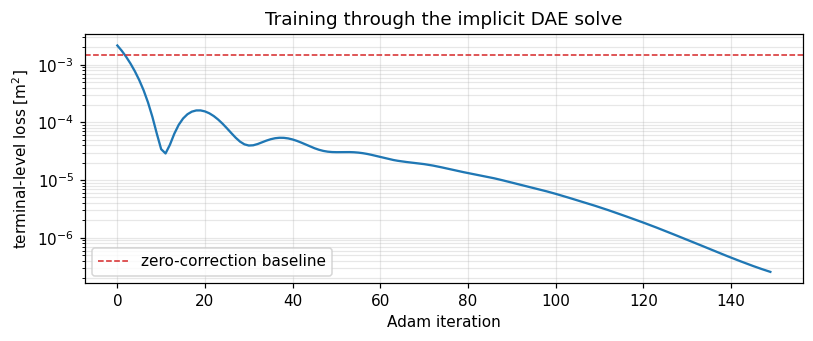

In [13]:
fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.semilogy(hist, lw=1.5)
ax.axhline(l_uncorrected, color="tab:red", ls="--", lw=1,
           label="zero-correction baseline")
ax.set_xlabel("Adam iteration")
ax.set_ylabel("terminal-level loss [m$^2$]")
ax.set_title("Training through the implicit DAE solve"
             + ("" if USE_PUBLICATION else " (fast mode)"))
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

*Figure 2: terminal-level loss vs Adam iteration (log scale); dashed red = the nominal model with the correction zeroed. Every iteration is nine reverse-differentiated BDF solves of the constrained system.*

> **Fast vs publication.** Default mode shows the offline run: 150 iterations on the full 3×3 excitation-horizon set, loss $2.16\times10^{-3} \to 2.56\times10^{-7}$ — a ~8,500× reduction, and ~5,700× below the zero-correction baseline; the first `value_and_grad` costs about a minute of jit compilation, after which a jitted iteration (nine DAE solves plus their reverse passes) runs in ~0.16 s. Fast mode runs 8 live iterations on a 2×2 subset — in our fast runs the loss falls ~9× and the recovery below lands at correlation ~0.98 with ~35% amplitude error (a few iterations shape the function much faster than they calibrate its scale); nothing else changes, so re-running with the NPZ present shows the full result.

### 4.4 Validation: recover the *function*, not the loss

A falling loss is a weak claim — Section 4.1's unstructured correction falls too. The strong claim is **function recovery**: the trained $\delta m(h_1, h_2)$, evaluated on a grid over the state region the training trajectories actually visit, should reproduce the *injected* residual — the known flow deficit of the clogged orifice,

$$\delta m^{\text{true}}(h_1, h_2) = (k_{12}^{\text{true}} - k_{12}^{\text{nom}})\, \frac{\Delta P}{(\Delta P^2 + \varepsilon)^{1/4}}, \qquad \Delta P = \rho g (h_1 - h_2),$$

which we can write down analytically because we injected the fault ourselves.

In [14]:
def injected_dm(h1, h2):
    """The flow deficit the clog injects: (k_true - k_nom) * orifice law."""
    dP = RHO * G_N * (h1 - h2)
    return (K12_TRUE - K12_NOMINAL) * dP / (dP**2 + EPS_V) ** 0.25


def learned_dm(h1, h2, theta):
    """The trained correction, converted back to physical kg/s."""
    p = unravel(theta)
    x_scaled = jnp.array([h1, h2]) * SC_ROWS
    z = jnp.tanh(x_scaled @ p["w1"] + p["b1"])
    return float(FLOW_SCALE * jnp.tanh(z @ p["w2"] + p["b2"])[0])


# the state region the training trajectories visit
h1s = np.linspace(0.26, 0.47, 12)
h2s = np.linspace(0.13, 0.24, 12)
inj = np.array([[injected_dm(a, b) for b in h2s] for a in h1s])
lrn = np.array([[learned_dm(a, b, theta_best) for b in h2s] for a in h1s])

rel = np.abs(lrn - inj).mean() / np.abs(inj).mean()
corr = np.corrcoef(lrn.ravel(), inj.ravel())[0, 1]
print(f"injected deficit on the grid: mean |dm| = {np.abs(inj).mean():.4f} kg/s, "
      f"peak {np.abs(inj).max():.4f} kg/s")
print(f"recovery: mean relative error = {rel:.2%}, correlation = {corr:.3f}")
if USE_PUBLICATION:
    print(f"offline-run values (cross-check): rel err = "
          f"{float(pub['d1_rel_err']):.2%}, corr = {float(pub['d1_corr']):.3f}")

injected deficit on the grid: mean |dm| = 0.0553 kg/s, peak 0.0780 kg/s
recovery: mean relative error = 1.43%, correlation = 0.996
offline-run values (cross-check): rel err = 1.43%, corr = 0.996


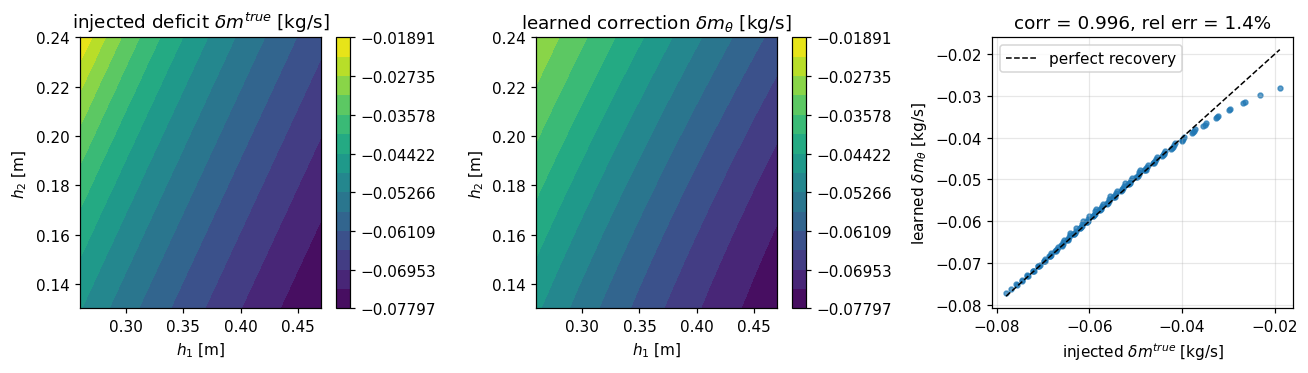

In [15]:
H1G, H2G = np.meshgrid(h1s, h2s, indexing="ij")
lv = np.linspace(min(inj.min(), lrn.min()), max(inj.max(), lrn.max()), 15)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
c0 = axes[0].contourf(H1G, H2G, inj, levels=lv, cmap="viridis")
axes[0].set_title("injected deficit $\\delta m^{true}$ [kg/s]")
c1 = axes[1].contourf(H1G, H2G, lrn, levels=lv, cmap="viridis")
axes[1].set_title("learned correction $\\delta m_\\theta$ [kg/s]")
for a in axes[:2]:
    a.set_xlabel("$h_1$ [m]")
    a.set_ylabel("$h_2$ [m]")
fig.colorbar(c0, ax=axes[0]); fig.colorbar(c1, ax=axes[1])

axes[2].scatter(inj.ravel(), lrn.ravel(), s=10, alpha=0.7)
ex = [inj.min(), inj.max()]
axes[2].plot(ex, ex, "k--", lw=1, label="perfect recovery")
axes[2].set_xlabel("injected $\\delta m^{true}$ [kg/s]")
axes[2].set_ylabel("learned $\\delta m_\\theta$ [kg/s]")
axes[2].set_title(f"corr = {corr:.3f}, rel err = {rel:.1%}")
axes[2].legend()
axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.show()

*Figure 3: function recovery on the visited region of the $(h_1, h_2)$ plane. Left: the analytically known flow deficit injected by the clog. Center: the trained neural correction converted to kg/s. Right: point-by-point scatter against the perfect-recovery diagonal; the only visible deviation is at the smallest deficits — the near-equal-levels corner of the grid, which the training trajectories barely visit.*

In publication mode the structured correction recovers the injected residual to **1.4% mean relative error with correlation 0.996** — from eighteen terminal-level numbers. Contrast that against the unstructured variant's 0.7–0.8 correlation at a comparable loss reduction: the difference is entirely the rank-1 flow prior of eq. (6). This is the notebook's central lesson — *put the physics you are sure of into the architecture, and spend the data only on what you genuinely don't know.*

Learning components inside DAEs is an active research problem, usually approached by splitting the differential and algebraic parts and learning a surrogate for the algebraic solve — see Koch, Shapiro, Sharma, Vrabie and Drgoňa, "Learning Neural Differential Algebraic Equations via Operator Splitting" (CDC 2025). Here the same tank-manifold benchmark shape trains through the *coupled* solve directly, because the solver itself is differentiable.

### 4.5 The constraint never moved

One more check, and it is the one that separates "neural DAE" from "neural ODE with extra steps": the flow-balance constraint must hold at solver tolerance **whether or not the learned term is active** — it is enforced by the BDF corrector at every step of every training iteration, never by a penalty. We evaluate the raw algebraic residual $\|g\|_\infty$ at simulated terminal states, before and after learning.

In [16]:
CHECK_OPTS = jx.SimulatorOptions(math_backend="jax", ode_solver_method="bdf",
                                 rtol=1e-7, atol=1e-9, enable_autodiff=False,
                                 max_major_steps=400)
MODEL_MASK = algebraic_row_mask(model_diagram)


def alg_residual_max(theta, exc, T):
    """Simulate the corrected model, then evaluate the algebraic rows of the
    RHS at the terminal state: for zero mass-matrix rows, xdot IS g(x,y,u)."""
    ctx = set_excitation(model_diagram, model_ctx0, model_consts, MODEL_SID, exc)
    ctx = ctx.with_subcontext(MODEL_SID,
                              ctx[MODEL_SID].with_parameter("nn_theta", theta))
    r = jx.simulate(model_diagram, ctx, (0.0, T), options=CHECK_OPTS)
    xdot = model_diagram.eval_time_derivatives(r.context)
    flat = np.concatenate([np.ravel(np.asarray(l)) for l in jax.tree.leaves(xdot)])
    return float(np.abs(flat[MODEL_MASK]).max())


exc0 = EXCITATIONS[0]
print("max |g| at simulated terminal states (solver atol = 1e-9):")
for label, th in (("before learning (theta_0)", theta0),
                  ("after learning  (theta*) ", theta_best)):
    for T in (8.0, 32.0):
        print(f"  {label}  T={T:4.0f} s:  {alg_residual_max(th, exc0, T):.2e}")

max |g| at simulated terminal states (solver atol = 1e-9):


  before learning (theta_0)  T=   8 s:  1.22e-10


  before learning (theta_0)  T=  32 s:  4.55e-13


  after learning  (theta*)   T=   8 s:  1.63e-11


  after learning  (theta*)   T=  32 s:  4.55e-13


The residual sits at the solver's tolerance floor in all four cases — the learned term changed *what* the differential rows do, and had no way to touch *whether* the constraint holds. In residual-loss PINN terms: this constraint is satisfied below $10^{-9}$ at every training step for free, instead of being a loss term fighting the data term for weight.

## 5. Direction 2 — train a torch policy *through* the jaxonomy DAE

Now the gradient crosses the other way. NEUROMANCER trains control policies by backpropagating a rollout loss through the plant model; in its own examples that plant is a PyTorch module. Here the plant is the jaxonomy DAE — implicit solver, algebraic constraint and all — and NEUROMANCER's `System`, `PenaltyLoss` and `Trainer` are used **completely unmodified**. The entire integration is one `torch.autograd.Function`:

1. **Forward** — one control interval per call (`DT` = 2 s, an FMI-style communication interval, foreshadowing Part 3): write the batch of levels into the differential rows, set the inputs, **value-only Newton projection** of the algebraic rows (Pitfalls 1 and 2, exactly as in Direction 1), then a `jax.vmap`-batched, jitted BDF solve over the interval.
2. **Backward** — the JAX VJP of that same batched step, jitted once.
3. **The boundary** — tensors cross via `dlpack`, zero-copy in both directions: torch and JAX share the same CPU buffers, so a 16-sample batch costs microseconds to hand over.

In [17]:
DT = 2.0        # communication interval / control period [s]
NSTEPS = 25     # rollout horizon in training (50 s)
PUMP_MAX = 100.0

BRIDGE_OPTS = jx.SimulatorOptions(math_backend="jax", ode_solver_method="bdf",
                                  rtol=1e-7, atol=1e-9, enable_autodiff=True,
                                  max_major_steps=64)

# The plant is Section 3's nominal diagram. Its continuous state stacks the
# 2 scaled levels with the 18 algebraic entries; levels map linearly onto
# the differential rows.
cs0 = jnp.asarray(plant_ctx0[PLANT_SID].continuous_state)
scale = np.asarray(cs0[:2]) / np.array([H1_IC, H2_IC])  # diff rows = scale * h
print(f"state scale factors: {scale},  full state size: {cs0.shape}")

_pump_id = plant_consts["pump_power"].system_id
_va_id = plant_consts["valve_a_opening"].system_id
_vb_id = plant_consts["valve_b_opening"].system_id


def _step(x_levels, u):
    """One DT interval. x_levels: (2,) tank levels [m]; u = (pump in [0,1],
    split v in [0,1]) -> valve A opens 1-v, valve B opens v."""
    n = cs0.at[0].set(scale[0] * x_levels[0]).at[1].set(scale[1] * x_levels[1])
    ctx = plant_ctx0.with_subcontext(
        PLANT_SID, plant_ctx0[PLANT_SID].with_continuous_state(n))
    # inputs first: the algebraic rows (manifold pressure, flows) depend on u
    ctx = ctx.with_subcontext(_pump_id, ctx[_pump_id].with_parameter(
        "value", u[0] * PUMP_MAX))
    ctx = ctx.with_subcontext(_va_id, ctx[_va_id].with_parameter(
        "value", 1.0 - u[1]))
    ctx = ctx.with_subcontext(_vb_id, ctx[_vb_id].with_parameter(
        "value", u[1]))
    # value-only projection of the algebraic rows onto g(x, y, u) = 0
    ctx_p = project_constraints(plant_diagram, ctx, tol=1e-12, max_iter=32)
    state_used = n + jax.lax.stop_gradient(ctx_p[PLANT_SID].continuous_state - n)
    ctx = ctx.with_subcontext(
        PLANT_SID, ctx[PLANT_SID].with_continuous_state(state_used))
    r = jx.simulate(plant_diagram, ctx, (0.0, DT), options=BRIDGE_OPTS)
    cse = r.context[PLANT_SID].continuous_state
    return jnp.array([cse[0] / scale[0], cse[1] / scale[1]])


step_batch = jax.jit(jax.vmap(_step))          # batched forward


def step_vjp(x, u, ct):
    y, pull = jax.vjp(lambda a, b: jax.vmap(_step)(a, b), x, u)
    return pull(ct)


step_vjp = jax.jit(step_vjp)                    # batched reverse

state scale factors: [2.5        6.66666667],  full state size: (20,)


In [18]:
def t2j(t):
    return jax.dlpack.from_dlpack(t.contiguous())


def j2t(x):
    return torch.from_dlpack(x)


class JaxDAEStep(torch.autograd.Function):
    """One batched DT-interval of the jaxonomy DAE, as a torch op."""

    nan_grad_events = 0  # counter for the sanitization guard (see below)

    @staticmethod
    def forward(ctx, x, u):
        x64, u64 = t2j(x.detach().double()), t2j(u.detach().double())
        y = step_batch(x64, u64)
        ctx.save_for_backward(x, u)
        return j2t(y).float()

    @staticmethod
    def backward(ctx, gy):
        x, u = ctx.saved_tensors
        gx, gu = step_vjp(t2j(x.detach().double()), t2j(u.detach().double()),
                          t2j(gy.contiguous().double()))
        gx, gu = j2t(gx).float(), j2t(gu).float()
        # the reverse pass through the adaptive BDF solve can emit NaN for
        # rare knife-edge trajectories whose forward value is finite;
        # sanitize (the analog of gradient clipping) and count occurrences
        if not (torch.isfinite(gx).all() and torch.isfinite(gu).all()):
            JaxDAEStep.nan_grad_events += 1
            gx = torch.nan_to_num(gx, nan=0.0, posinf=0.0, neginf=0.0)
            gu = torch.nan_to_num(gu, nan=0.0, posinf=0.0, neginf=0.0)
        return gx, gu


# ---- smoke test: timings + gradient check through the bridge ---------------
B = 4
x = torch.rand(B, 2) * 0.4 + 0.1
u = torch.rand(B, 2) * 0.5 + 0.25
u.requires_grad_(True)

t0 = time.perf_counter()
y = JaxDAEStep.apply(x, u)
print(f"first batched DAE step (incl jit): {time.perf_counter() - t0:.1f}s;  "
      f"y[0] = {y[0].detach().numpy()}")
t0 = time.perf_counter()
y = JaxDAEStep.apply(x, u)
t_fwd = time.perf_counter() - t0
print(f"steady batched forward: {1e3 * t_fwd:.1f} ms")

loss_smoke = (y ** 2).sum()
t0 = time.perf_counter()
loss_smoke.backward()
print(f"first backward (incl jit): {time.perf_counter() - t0:.1f}s")
g_ad = u.grad.clone()

u.grad = None
y = JaxDAEStep.apply(x, u)  # fresh graph for a steady-state backward timing
t0 = time.perf_counter()
(y ** 2).sum().backward()
t_bwd = time.perf_counter() - t0
print(f"steady batched backward: {1e3 * t_bwd:.0f} ms "
      f"({t_bwd / t_fwd:.0f}x the forward step — the reverse pass "
      f"recomputes the solve between checkpoints; budget training "
      f"accordingly)")

eps = 1e-3
i, jdx = 1, 0
up = u.detach().clone(); up[i, jdx] += eps
um = u.detach().clone(); um[i, jdx] -= eps
fd = ((JaxDAEStep.apply(x, up) ** 2).sum()
      - (JaxDAEStep.apply(x, um) ** 2).sum()) / (2 * eps)
ad = float(g_ad[i, jdx])
print(f"bridge gradcheck d/du[{i},{jdx}]:  AD = {ad:+.6e}   "
      f"FD = {float(fd):+.6e}   rel diff = {abs(ad - float(fd)) / abs(float(fd)):.1e}")

first batched DAE step (incl jit): 5.1s;  y[0] = [0.31574255 0.39471883]
steady batched forward: 2.8 ms


first backward (incl jit): 15.1s
steady batched backward: 142 ms (50x the forward step — the reverse pass recomputes the solve between checkpoints; budget training accordingly)
bridge gradcheck d/du[1,0]:  AD = +5.957320e-03   FD = +5.960464e-03   rel diff = 5.3e-04


A steady batched forward step runs in ~3 ms once jitted; the *backward* step is roughly 50× more expensive, because reverse-mode through an adaptive implicit solver recomputes segments of the solve between checkpoints. That asymmetry — cheap rollouts, costly gradients — sets the training budget for everything below. The finite-difference check crosses **two frameworks and an implicit solver** and still matches to ~$10^{-3}$ relative — the FD side is float32 torch arithmetic with $\varepsilon = 10^{-3}$, so that is the comparison's floor, not the gradient's quality.

### 5.1 Robustness guards — co-simulation practice, not apologies

Training samples random initial levels and random setpoints, so the rollout *will* visit awkward corners of the state-input space. Three guards, all standard practice for any co-simulation master or RL-on-simulator loop, and all **counted and reported** rather than silent:

- **Level clamp** `[0.02, 0.95]` on the plant input — levels are physically confined to the tank; the psl reference models in Part 1 clip inside their own equations for the same reason.
- **Hold state on solver failure** — if the BDF step returns non-finite values for a sample, that sample keeps its pre-step state for the interval (a co-sim master's retry/hold), detached so no gradient flows through the substitution. Counted per event, and the offending $(x, u)$ points are recorded.
- **NaN-gradient sanitization** in `backward` (above) — the reverse pass at a knife-edge point can NaN even when the forward pass is finite; `nan_to_num` is the bridge analog of gradient clipping. Counted per event.

In the offline 15-epoch run both counters fire — and every single event traces to **one isolated knife-edge point** in the sampled data (reported below), not to a diffuse instability.

In [19]:
# NEUROMANCER's abstractions, exactly as its own examples use them — the
# only unusual piece is that the plant Node wraps an implicit DAE solve.
from neuromancer.callbacks import Callback
from neuromancer.constraint import variable
from neuromancer.dataset import DictDataset
from neuromancer.loss import PenaltyLoss
from neuromancer.modules import blocks
from neuromancer.problem import Problem
from neuromancer.system import Node, System
from neuromancer.trainer import Trainer

BAD_POINTS = []


class JaxPlant(nn.Module):
    """The jaxonomy DAE as a NEUROMANCER plant node, with co-sim guards."""

    def forward(self, x, u):
        xc = x.clamp(0.02, 0.95)       # levels are physically confined
        y = JaxDAEStep.apply(xc, u)
        bad = ~torch.isfinite(y).all(dim=-1)
        if bad.any():                  # hold state on solver failure
            BAD_POINTS.append(np.concatenate([xc[bad].detach().numpy(),
                                              u[bad].detach().numpy()], axis=1))
            y = torch.where(bad.unsqueeze(-1), xc.detach(), y)
        return y


plant_node = Node(JaxPlant(), ['x', 'u'], ['x'], name='dae_plant')
# pump floor 0.05: an idling pump keeps the pump equation regular (Section 2)
policy = blocks.MLP_bounds(insize=4, outsize=2, hsizes=[32, 32], nonlin=nn.GELU,
                           min=torch.tensor([0.05, 0.0]), max=torch.ones(2))
policy_node = Node(policy, ['x', 'r'], ['u'], name='policy')
cl = System([policy_node, plant_node], nsteps=NSTEPS)


def make_ds(n, name):
    x0 = torch.rand(n, 1, 2) * 0.4 + 0.05
    r = (torch.rand(n, 1, 2) * 0.5 + 0.15).repeat(1, NSTEPS + 1, 1)
    return DictDataset({'x': x0, 'r': r}, name=name)


train_d, dev_d = make_ds(64, 'train'), make_ds(16, 'dev')
tl = torch.utils.data.DataLoader(train_d, batch_size=16,
                                 collate_fn=train_d.collate_fn, shuffle=True)
dl = torch.utils.data.DataLoader(dev_d, batch_size=16,
                                 collate_fn=dev_d.collate_fn)

xv, rv, uv = variable('x'), variable('r'), variable('u')
obj = 5.0 * ((xv == rv) ^ 2); obj.name = 'tracking'
du = 0.1 * ((uv[:, 1:, :] == uv[:, :-1, :]) ^ 2); du.name = 'smooth'
problem = Problem([cl], PenaltyLoss([obj, du], []))


class CurveLogger(Callback):
    """Capture the per-epoch mean train/dev losses the Trainer computes."""

    def __init__(self):
        self.train_curve, self.dev_curve = [], []

    def begin_eval(self, trainer, output):
        self.train_curve.append(float(output['mean_train_loss']))
        if 'mean_dev_loss' in output:
            self.dev_curve.append(float(output['mean_dev_loss']))


print(f"closed-loop system: {NSTEPS}-step rollouts, {DT}s interval, "
      f"batch 16; policy has "
      f"{sum(p.numel() for p in policy.parameters())} parameters")

closed-loop system: 25-step rollouts, 2.0s interval, batch 16; policy has 1282 parameters


In [20]:
if USE_PUBLICATION:
    sd = {k.split("::", 1)[1]: torch.tensor(v)
          for k, v in pub.items() if k.startswith("d2_policy::")}
    policy.load_state_dict(sd)
    train_curve = np.asarray(pub["d2_train_curve"])
    dev_curve = np.asarray(pub["d2_dev_curve"])
    nan_events = int(pub["d2_nan_grad_events"])
    held_events = int(pub["d2_held_state_events"])
    print(f"loaded policy trained offline: {int(pub['d2_epochs'])} epochs in "
          f"{float(pub['d2_train_wall_s']) / 60:.1f} min")
else:
    D2_EPOCHS_FAST = 2
    curves = CurveLogger()
    opt2 = torch.optim.AdamW(problem.parameters(), lr=3e-3)
    t0 = time.perf_counter()
    trainer = Trainer(problem, tl, dl, optimizer=opt2, epochs=D2_EPOCHS_FAST,
                      train_metric='train_loss', dev_metric='dev_loss',
                      eval_metric='dev_loss', warmup=D2_EPOCHS_FAST,
                      callback=curves)
    best_state = trainer.train()
    problem.load_state_dict(best_state)
    print(f"fast training: {D2_EPOCHS_FAST} epochs in "
          f"{time.perf_counter() - t0:.0f}s")
    train_curve = np.asarray(curves.train_curve)
    dev_curve = np.asarray(curves.dev_curve)
    nan_events = JaxDAEStep.nan_grad_events
    held_events = sum(len(b) for b in BAD_POINTS)

print(f"train_loss: {train_curve[0]:.3f} -> {train_curve[-1]:.3f} "
      f"over {train_curve.size} epochs")
print(f"guard counters: {nan_events} sanitized NaN-gradient batches, "
      f"{held_events} held-state solver failures")
if USE_PUBLICATION and held_events:
    bp = np.unique(np.asarray(pub["d2_bad_points"]).round(3), axis=0)
    print(f"all held-state events sit at {bp.shape[0]} distinct (x1,x2,u1,u2) "
          f"point(s): {bp.tolist()}")

loaded policy trained offline: 15 epochs in 11.8 min
train_loss: 0.192 -> 0.151 over 15 epochs
guard counters: 24 sanitized NaN-gradient batches, 24 held-state solver failures
all held-state events sit at 1 distinct (x1,x2,u1,u2) point(s): [[0.35100001096725464, 0.06800000369548798, 0.6309999823570251, 0.4690000116825104]]


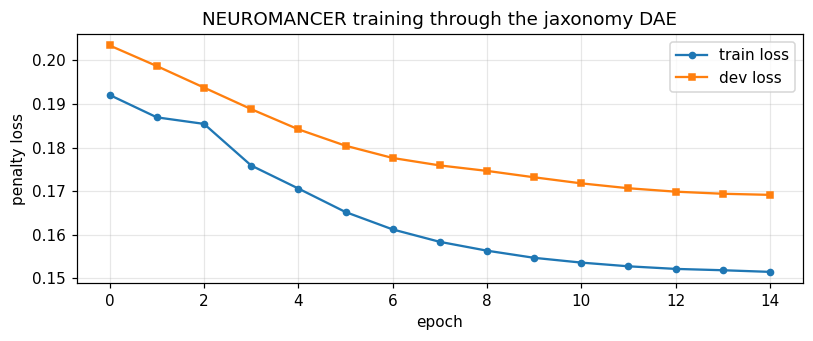

In [21]:
fig, ax = plt.subplots(figsize=(7.5, 3.2))
ep = np.arange(train_curve.size)
ax.plot(ep, train_curve, "-o", ms=4, label="train loss")
if dev_curve.size:
    ax.plot(np.arange(dev_curve.size), dev_curve, "-s", ms=4, label="dev loss")
ax.set_xlabel("epoch")
ax.set_ylabel("penalty loss")
ax.set_title("NEUROMANCER training through the jaxonomy DAE"
             + ("" if USE_PUBLICATION else " (fast mode)"))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

*Figure 4: NEUROMANCER `Trainer` loss per epoch; every batch is 25 DAE-solve steps forward and 25 VJPs backward across the dlpack bridge.*

The descent is monotone and unspectacular — which is the point: a stock PyTorch training loop neither knows nor cares that its plant hides an implicit solver with 18 algebraic unknowns. Wall time is dominated by the backward bridge steps (each epoch is 4 batches × 25 reverse-mode DAE solves), which is why the offline run affords only 15 epochs = **60 gradient updates** — tiny by DPC standards, where policies routinely see thousands of updates on cheap ODE plants.

### 5.2 Closed-loop evaluation

Calibrate expectations before looking: 60 updates buys a *mid-training snapshot*, not a converged controller — the dev loss is still falling at the last epoch. Most training scenarios start below their reference, so the transient fill dominates the finite-horizon objective, and an early policy learns "pump hard toward the setpoint region" before it learns to modulate and hold. We evaluate the canonical rollout anyway — both tanks from $(0.40, 0.15)$ m to a 0.30 m setpoint, 40 steps of 2 s — and report what we get; note the rollout deliberately runs to 80 s, *past* the 50 s training horizon, to expose extrapolation behavior too.

> **Note (fast mode).** Without the NPZ this section evaluates the 2-epoch live policy instead, and the numbers differ — in our runs the *less*-trained policy happens to land closer on this one setpoint (a gentler fill, RMS ≈ 0.017 m) while being clearly worse on the training distribution (compare dev losses). A single-rollout eval is a noisy instrument; that, too, is part of the lesson.

In [22]:
with torch.no_grad():
    data = {'x': torch.tensor([[[0.40, 0.15]]]),
            'r': torch.full((1, 41, 2), 0.30)}
    cl.nsteps = 40
    out = cl(data)
xs = out['x'][0].numpy()
us = out['u'][0].numpy()
t_cl = np.arange(xs.shape[0]) * DT

rms = float(np.sqrt(((xs[20:] - 0.30) ** 2).mean()))
print(f"final levels: h1 = {xs[-1, 0]:.3f} m, h2 = {xs[-1, 1]:.3f} m "
      f"(target 0.30 m)")
print(f"tracking RMS over the last half of the rollout: {rms:.4f} m")
if USE_PUBLICATION:
    drift = float(np.abs(xs - np.asarray(pub["d2_x_traj"])).max())
    print(f"reproducibility vs the offline rollout: max |dh| = {drift:.2e} m")

final levels: h1 = 0.451 m, h2 = 0.414 m (target 0.30 m)
tracking RMS over the last half of the rollout: 0.0988 m
reproducibility vs the offline rollout: max |dh| = 0.00e+00 m


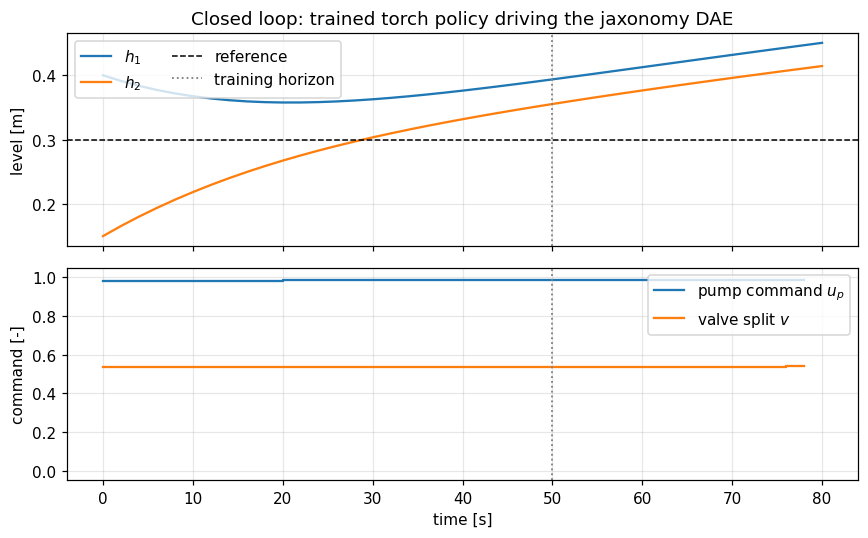

In [23]:
fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
axes[0].plot(t_cl, xs[:, 0], label="$h_1$")
axes[0].plot(t_cl, xs[:, 1], label="$h_2$")
axes[0].axhline(0.30, color="k", ls="--", lw=1, label="reference")
axes[0].axvline(NSTEPS * DT, color="gray", ls=":", lw=1.2,
                label="training horizon")
axes[0].set_ylabel("level [m]")
axes[0].set_title("Closed loop: trained torch policy driving the jaxonomy DAE")
axes[0].legend(loc="upper left", ncols=2)
axes[0].grid(alpha=0.3)

t_u = np.arange(us.shape[0]) * DT
axes[1].step(t_u, us[:, 0], where="post", label="pump command $u_p$")
axes[1].step(t_u, us[:, 1], where="post", label="valve split $v$")
axes[1].axvline(NSTEPS * DT, color="gray", ls=":", lw=1.2)
axes[1].set_xlabel("time [s]")
axes[1].set_ylabel("command [-]")
axes[1].set_ylim(-0.05, 1.05)
axes[1].legend(loc="upper right")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

*Figure 5: closed-loop rollout from $(0.40, 0.15)$ m toward a common 0.30 m setpoint; dotted gray = the 50 s training horizon. In the publication run shown here, $h_2$ climbs through its setpoint and overshoots, while $h_1$ dips only slightly before the shared full-power fill pulls it back up; past the training horizon both levels keep drifting upward. Bottom: the policy's pump and valve-split commands at the 2 s interval.*

Read the publication-mode result honestly. Within its training horizon the policy does what its objective rewarded — a fast coordinated fill that carries $h_2$ from 0.15 into the setpoint's neighborhood — but it holds the pump near full power throughout, barely modulating with the state, and past 50 s it extrapolates poorly: the levels drift above the reference and the tracking RMS printed above reflects that. Three structural reasons, all instructive: the update budget is 60; the finite-horizon objective is transient-dominated (holding a level contributes little loss mass compared to reaching it); and the policy has no integral action, so a steady offset costs it less than you'd expect. Exercise 4 attacks this directly. **What is demonstrated here is the mechanics** — gradients of a rollout loss flowing through 25 chained implicit DAE solves into a torch policy, with NEUROMANCER's trainer none the wiser — not a production level controller.

### 5.3 Diagnostics on the final loop

Per this project's practice for any closed-loop notebook, we run the actuator diagnostics rather than eyeballing Figure 5: saturation fractions for both commands against their training bounds, and zero-crossing rates to catch bang-bang behavior. We widen the saturation tolerance to 2% of range: the bounded policy's sigmoid-style output can hug a rail without ever mathematically reaching it, and "within 2% of the rail" is the operationally honest notion of saturated here.

In [24]:
# atol=0.02: count "within 2% of a rail" as saturated (see note above)
sat_pump = analyze_saturation(us[:, 0], lower=0.05, upper=1.0, atol=0.02,
                              mode="upper_only", name="pump command")
sat_valve = analyze_saturation(us[:, 1], lower=0.0, upper=1.0, atol=0.02,
                               name="valve split")
osc_pump = analyze_control_oscillation(us[:, 0], t_u, name="pump command")
osc_valve = analyze_control_oscillation(us[:, 1], t_u, name="valve split")

for report in (sat_pump, sat_valve, osc_pump, osc_valve):
    print(report.message)
n_warn = sum(r.warning_triggered
             for r in (sat_pump, sat_valve, osc_pump, osc_valve))
print(f"\ndiagnostic warnings triggered: {n_warn}")

pump command: 100% at upper=1, 0% at lower=0.05. [upper_only mode; only upper rail counts against threshold] Total saturated: 100% of 40 samples.
valve split: 0% at upper=1, 0% at lower=0. Total saturated: 0% of 40 samples.
pump command: 1 sign changes over 78.00 s = 0.01 crossings/s
valve split: 2 sign changes over 78.00 s = 0.03 crossings/s

diagnostic warnings triggered: 1


/var/folders/bb/_sl__30n6wjdgtkt6n3cyw6r0000gn/T/ipykernel_76716/530443669.py:2: UserWarning: [analyze_saturation] pump command: 100% at upper=1, 0% at lower=0.05. [upper_only mode; only upper rail counts against threshold] Total saturated: 100% of 40 samples. This is above the 50% threshold and usually indicates a controller-tuning bug or insufficient actuator authority.
  sat_pump = analyze_saturation(us[:, 0], lower=0.05, upper=1.0, atol=0.02,


The reports quantify what Figure 5 shows qualitatively. In the publication run the pump saturation warning fires — **expected and acknowledged, not fixed**: a mid-training fill-dominated policy rides its upper pump rail for essentially the whole rollout, a controller-maturity finding rather than a sign error (a sign error would show as the *wrong* rail, or as oscillation). The valve split sits mid-range and neither command oscillates: zero-crossing rates are far below the 5/s bang-bang threshold. (In fast mode the 2-epoch policy pumps more gently and no warning triggers — the single-rollout noise noted in Section 5.2.) If this were a shipping controller, the publication-mode saturation report alone would send it back to training — which is precisely what these diagnostics are for.

## 6. Failure modes

Concrete regimes where the machinery of this notebook breaks, all encountered while building it:

- **Pump-law singularity at zero power.** Eq. (4) loses all $\Delta P$ sensitivity as $u_p \to 0$, and without the bypass the algebraic Jacobian's manifold-pressure pivot vanishes — the Newton solve inside both `project_constraints` and the BDF corrector goes singular. The bypass valve and the policy's 5% pump floor exist for this; delete either and random exploration finds the singularity within an epoch.
- **Projection needs a sane seed and enough iterations.** The algebraic initial values are solved for the build-time placeholder inputs, which then seed every Newton projection. Centered placeholders (`CENTER`) keep every operating point reachable; building with a corner placeholder (pump ~0 W) makes projections diverge. Iteration budget matters too: with `max_iter=12` one benign-looking training sample NaN'd — the run only became clean at `max_iter=32`. Symptom either way: sporadic per-sample NaNs that look like solver bugs and are actually bad warm starts.
- **Reverse-AD cost across long horizons.** Direction 1 differentiates through up to 32 s of adaptive BDF stepping with checkpointing; Direction 2 keeps torch's graph across 25 bridge calls, each holding its own VJP closure. Memory scales with horizon length — doubling `NSTEPS` roughly doubles resident graph — and time is asymmetric: the steady *backward* bridge step costs ~50× the ~3 ms forward, because the reverse pass recomputes solve segments between checkpoints. That asymmetry, not the plant itself, is what capped the offline run at 60 gradient updates; mitigations (shorter intervals, truncated BPTT, more checkpoints) all trade compute for memory or bias.
- **The correction bound must dominate the true residual.** `FLOW_SCALE` = 0.15 kg/s against an injected deficit peaking at ~0.08 kg/s. Set the bound *below* the truth (say 0.05) and the tanh saturates: the loss plateaus at a floor no optimizer can cross, and — more insidiously — the recovered function is a clipped, distorted version of the truth. Bounds encode "how big can the unknown physics be"; if you do not know, start generous and shrink.

## 7. Exercises

1. **Milder clogs (code, easy).** Set `K12_TRUE = 0.8 * K12_NOMINAL` and rerun in fast mode. The injected deficit shrinks by ~2.5×. At what severity does the recovery correlation drop below 0.9 — and is the limit the data, the solver tolerance, or `FLOW_SCALE`?
2. **Break the prior (code, medium).** Replace `nn_fn` with an unstructured 2-in/2-out correction (two independent tanh-bounded outputs, one per level equation) and retrain. Verify Section 4.1's claim on your own machine: the loss still falls by orders of magnitude while the scatter plot of Figure 3 degrades to correlation ~0.7–0.8. Identifiability, not capacity, is the binding constraint.
3. **Projection gradients (conceptual).** The reset projection is applied value-only. Using the implicit function theorem on $g(\mathbf{x}_0, \mathbf{y}_0, \mathbf{u}) = 0$, write the exact $\partial \mathbf{y}_0 / \partial \mathbf{u}$. Now explain why reverse-AD through 32 *unrolled* Newton iterations can differ from it badly when the iteration starts far from the solution but has converged by iteration 32 — and why the discrepancy contaminates $\partial \mathcal{L}/\partial \mathbf{u}$ even though the forward values agree to $10^{-12}$.
4. **Give the policy a memory (code, harder).** Section 5.2's steady offset is partly the absence of integral action. Add an integrator `Node` to the closed-loop `System` that accumulates `i += (r - x) * DT`, widen the policy to `insize=6` with inputs `['x', 'r', 'i']`, and retrain in fast mode. Does the offset shrink within the same update budget — and what happens to the guard counters now that the policy sees an unbounded input?
5. **One policy for a fleet (open-ended).** Part 1 swept plant parameters *after* training; here you can sweep them *during* training: `vmap` `_step` over a batch of drain coefficients `k_out` and train a single policy against the ensemble. Explore how the guards' event counts scale with spread, whether the policy learns to be conservative, and what reference regions become infeasible for the worst plants in the batch.

## 8. Key takeaways

- **Acausal components turn topology into constraints.** The 3-way manifold's pressure is an algebraic unknown created by `connect()`, not an equation anyone wrote; the compiler emits a semi-explicit DAE (`n_ode=2`, `n_alg=18`) that BDF integrates directly.
- **Gradients flow through the implicit solve.** `jax.value_and_grad` through adaptive BDF with a singular mass matrix matches finite differences to ~5 significant digits — no hand-written adjoint, and the same VJP serves torch through `dlpack`.
- **Physics belongs in the architecture, not only the solver.** An unstructured correction fits 18 data points and recovers nothing (corr 0.7–0.8); the rank-1 "the unknown is a flow" prior recovers the injected residual to 1.4% / corr 0.996 from the same data.
- **Constraints are enforced by the solver, never a penalty.** The algebraic residual stays below $10^{-9}$ before, during, and after learning — there is no constraint-vs-data tradeoff to tune.
- **The stack boundary is one `autograd.Function`.** Zero-copy `dlpack`, a jitted vmapped forward (~ms per batch), a jitted VJP backward; NEUROMANCER's trainer runs unmodified.
- **Guards are part of the contract.** Reset projection, hold-on-failure, NaN sanitization — counted and reported (all offline-run events trace to one knife-edge sample), the same discipline a co-simulation master applies.

**Next steps.** [Part 3](pinn_across_stacks_part_3_fmi_cosim.ipynb) removes the shared runtime entirely: the same plant exported as an FMU and stepped in lockstep with the torch policy over FMI — the pattern for verification across organizational boundaries. For the diagram-authored neural-DAE API, see the [pendulum drag recovery tutorial](neural_dae_pendulum_drag.ipynb); for the projection machinery in isolation, the [DAE projection tutorial](dae_projection_pendulum.ipynb).

## References

1. J. Koch, M. Shapiro, H. Sharma, D. Vrabie, J. Drgoňa, *Learning Neural Differential Algebraic Equations via Operator Splitting*, IEEE Conference on Decision and Control (CDC), 2025 (arXiv preprint).
2. C. C. Pantelides, *The Consistent Initialization of Differential-Algebraic Systems*, SIAM J. Sci. Stat. Comput. 9(2), 213–231, 1988.
3. J. Drgoňa, A. Tuor, J. Koch, M. Shapiro, B. Jacob, D. Vrabie, *NeuroMANCER: Neural Modules with Adaptive Nonlinear Constraints and Efficient Regularizations*, PNNL, 2023. https://github.com/pnnl/neuromancer
4. Y. Cao, S. Li, L. Petzold, R. Serban, *Adjoint Sensitivity Analysis for Differential-Algebraic Equations: The Adjoint DAE System and Its Numerical Solution*, SIAM J. Sci. Comput. 24(3), 1076–1089, 2003.
5. K. E. Brenan, S. L. Campbell, L. R. Petzold, *Numerical Solution of Initial-Value Problems in Differential-Algebraic Equations*, SIAM Classics in Applied Mathematics, 1996.
6. R. T. Q. Chen, Y. Rubanova, J. Bettencourt, D. Duvenaud, *Neural Ordinary Differential Equations*, NeurIPS 2018.